## Primer
Monte Carlo Markov Chains is a group of algorithms that implement a **Random Approach** (Monte Carlo) used with **Markov Chains** to sample a statistical distribution.

We look at a **Markov Chain** as a sequence of Random Variables (states), in which each state depends only on the previous one.

Posterior distribution: $P(\hat{X}|\hat{y})$ - the probability of my parameters $\hat{X}$ having my data $\hat{y}$ is equal to the likelihood times the prior distribution (so the expectations of the parameters without any data).

## Metropolis Algorithm
### The main issue
When we want to sample from a complex probability distribution $\pi(x)$, we typically only know the *shape* of the distribution, but not its *scale*.

Normalized $\pi(x) = \frac{f(x)}{Z}$, where $Z = \int f(x)dx$, however we don't know the constant $Z$. In high-dimensional spaces, calculating $Z$ is computationally unfeasible, hence we cannot calculate the absolute probability $\pi(x)$, and traditional sampling methods fail.

In the Metropolis Algorithm (a MCMC method), we treat $\pi$ as a function and we call it the target probability density. It can be interpreted as the *shape*  we want to sample from.

The idea behind the Metropolis is: since we cannot calculate $Z$, let's cancel it out. We calculate the relative probability ratio between two states, the constant $Z$ automatically cancels out in the numerator and denominator: $$\frac{\pi(x_new)}{\pi(x_old)} = \frac{f(x_new)/Z}{f(x_old)/Z} = \frac{f(x_new)}{f(x_old)}$$.

The goal is to obtain samples from a static distribution $\pi$, by constructing a dynamic process (Markov chain).

We are given the target distribution $\pi$ and we need to design a transition matrix $P$ such that the chain eventually converges to $\pi$.
Metropolis constructs a special "accept/reject" rule via **Detailed Balance Principle**, generating an HIA chain on the fly. According to the ergodic theorem, the trajectory generated by this MC is statistically equivalent to samples drawn from the target distribution $Z$ in the long run.

## The Formal Metropolis Algorithm
### The Symmetry Requirement
The classical Metropolis algorithm requires a symmetric proposal distribution $q(x^* \mid x_t)$:$$q(x^* \mid x_t) = q(x_t \mid x^*)$$
This means the probability of proposing a jump from $x_t$ to $x^*$ is identical to proposing a jump from $x^*$ back to $x_t$ (e.g., a Gaussian step centered at the current state: $x^* \sim \mathcal{N}(x_t, \sigma^2 I)$).

Conceptually the proposal $q$ is a proposed transition matrix (or a proposed transition kernel in continuous space). The final transition matrix $P$ is created by filtering $Q$ through the acceptance probability $\alpha$.

### Step-by-Step Procedure
1. **Initialization:** Choose an arbitrary valid starting state $x_0 \in \mathcal{S}$ and set $t = 0$.
2. **Proposal:** At step $t$, draw a candidate state $x^*$ from the symmetric proposal distribution:$$x^* \sim q(x^* \mid x_t)$$
3. **Acceptance Ratio Calculation:** Compute the acceptance probability $\alpha(x_t, x^*)$:$$\alpha(x_t, x^*) = \min\left(1, \, \frac{\pi(x^*)}{\pi(x_t)}\right) = \min\left(1, \, \frac{\tilde{\pi}(x^*)}{\tilde{\pi}(x_t)}\right)$$
4. **Accept or Reject:** Draw a uniform random number $u \sim \text{Uniform}(0, 1)$.  If $u \le \alpha(x_t, x^*)$, accept the proposal:$$x_{t+1} = x^*$$If $u > \alpha(x_t, x^*)$, reject the proposal and keep the current state:$$x_{t+1} = x_t$$Increment and Repeat: Set $t \leftarrow t + 1$ and repeat steps 2–4 for $N$ iterations.

### Example

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Julia\AppData\Local\Temp\ipykernel_39680\3290811901.py:7: SyntaxWarning: invalid escape sequence '\p'
  Evaluates \tilde{\pi}(x) without knowing the normalizing constant Z.


Total iterations: 60000
Burn-in discarded: 500
Empirical Acceptance Rate: 58.33%


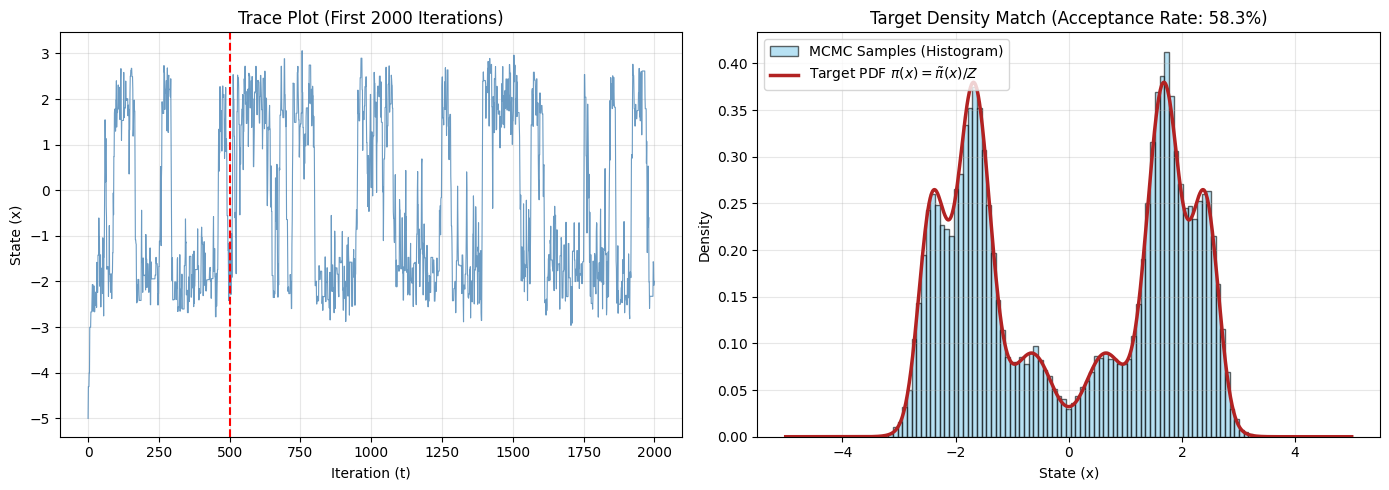

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the unnormalized target distribution \tilde{\pi}(x)
def unnormalized_target(x):
    """
    Evaluates \tilde{\pi}(x) without knowing the normalizing constant Z.
    """
    double_well = np.exp(-((x**2 - 4.0)**2) / 8.0)
    periodic_mod = 1.0 + np.sin(3.0 * x)**2
    return double_well * periodic_mod

# 2. Metropolis Sampler Implementation
def run_metropolis(n_iterations=50000, proposal_std=1.0, x_init=0.0):
    samples = np.empty(n_iterations)
    x_current = x_init
    pi_current = unnormalized_target(x_current)
    n_accepted = 0

    for t in range(n_iterations):
        # Symmetric proposal: q(x* | x) ~ uniform(-\sigma, \sigma)
        x_proposal = x_current + np.random.uniform(low=-proposal_std, high=proposal_std)
        pi_proposal = unnormalized_target(x_proposal)

        # Acceptance probability \alpha = min(1, \pi(x*) / \pi(x))
        # Z cancels out completely in the ratio!
        acceptance_ratio = pi_proposal / pi_current
        
        # Accept or reject
        if np.random.uniform(0.0, 1.0) < acceptance_ratio: # an acceptance ratio greater than 1 is always accepted
            x_current = x_proposal
            pi_current = pi_proposal
            n_accepted += 1

        samples[t] = x_current

    acceptance_rate = n_accepted / n_iterations
    return samples, acceptance_rate

# 3. Run the sampler
np.random.seed(42)
n_samples = 60000
burn_in = 500
step_size = 1.5

chain, acc_rate = run_metropolis(
    n_iterations=n_samples, 
    proposal_std=step_size, 
    x_init=-5.0  # Deliberately initialized far in the tail
)

# Discard burn-in samples
valid_samples = chain[burn_in:]

print(f"Total iterations: {n_samples}")
print(f"Burn-in discarded: {burn_in}")
print(f"Empirical Acceptance Rate: {acc_rate * 100:.2f}%")

# 4. Visualization
x_grid = np.linspace(-5.0, 5.0, 1000)
unnormalized_curve = unnormalized_target(x_grid)

# Numerical integration (trapezoidal rule) solely for ground-truth plotting comparison
dx = x_grid[1] - x_grid[0]
Z_approx = np.trapz(unnormalized_curve, x_grid)
true_normalized_pdf = unnormalized_curve / Z_approx

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Trace Plot (Visualizing the Markov Chain trajectory)
axes[0].plot(chain[:2000], color='steelblue', lw=0.8, alpha=0.8)
axes[0].axvline(burn_in if burn_in < 2000 else 2000, color='red', linestyle='--', label='Burn-in cutoff' if burn_in < 2000 else None)
axes[0].set_title("Trace Plot (First 2000 Iterations)")
axes[0].set_xlabel("Iteration (t)")
axes[0].set_ylabel("State (x)")
axes[0].grid(True, alpha=0.3)

# Plot B: Empirical Histogram vs. Normalized True Density
axes[1].hist(
    valid_samples, 
    bins=80, 
    density=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6, 
    label='MCMC Samples (Histogram)'
)
axes[1].plot(
    x_grid, 
    true_normalized_pdf, 
    color='firebrick', 
    lw=2.5, 
    label='Target PDF $\\pi(x) = \\tilde{\\pi}(x) / Z$'
)
axes[1].set_title(f"Target Density Match (Acceptance Rate: {acc_rate*100:.1f}%)")
axes[1].set_xlabel("State (x)")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Metropolis-Hasting

MH generalizes the original 1953 Metropolis algorithm by removing the requirement that candidate moves must be generated symmetrically. The acceptance probability is:$$\alpha(x, x^*) = \min\left(1, \, \underbrace{\frac{\pi(x^*)}{\pi(x)}}_{\text{Target Ratio}} \times \underbrace{\frac{q(x \mid x^*)}{q(x^* \mid x)}}_{\text{Hastings Ratio}}\right)$$

**What the Hastings Ratio Represents** 
The Hastings ratio $\frac{q(x \mid x^*)}{q(x^* \mid x)}$ is an asymmetry tax:
- **Denominator $q(x^* \mid x)$:** The probability density of proposing the forward move from $x$ to $x^*$.
- **Numerator $q(x \mid x^*)$:** The probability density of proposing the reverse return jump from $x^*$ back to $x$.

Detailed balance requires the two-way transition flux to match: $$\pi(x) \underbrace{q(x^* \mid x) \alpha(x, x^*)}_{P(x \to x^*)} = \pi(x^*) \underbrace{q(x \mid x^*) \alpha(x^*, x)}_{P(x^* \to x)}$$

Rearranging the terms:$$\frac{\alpha(x, x^*)}{\alpha(x^*, x)} = \frac{\pi(x^*) q(x \mid x^*)}{\pi(x) q(x^* \mid x)}$$

- If your proposal kernel has a built-in directional bias—such that jumping to $x^*$ is 5 times easier than jumping back ($q(x^* \mid x) = 5 \cdot q(x \mid x^*)$)—the proposal mechanism naturally oversupplies candidate moves toward $x^*$.
- The Hastings ratio evaluates to $\frac{1}{5} = 0.2$.
- This factor **downweights** the acceptance rate of that forward jump by a factor of 5, neutralizing the artificial directional drift so the chain samples strictly from $\pi(x)$.

**SUMMARIZING**
1. **Breaking the Symmetry Requirement:** You do not need a symmetric proposal ($q(x^* \mid x) = q(x \mid x^*)$). The Hastings ratio $\frac{q(x \mid x^*)}{q(x^* \mid x)}$ dynamically corrects for any directional bias in your proposal kernel.
2. **Enforcing Reversibility:** By design, the Metropolis-Hastings acceptance formula forces every single proposal to satisfy detailed balance ($\pi(x) P(x \to x^*) = \pi(x^*) P(x^* \to x)$). As we established, detailed balance guarantees that the Markov chain is reversible.
3. **The Necessity for MCMC:** Reversibility is a sufficient condition (and the standard constructive guarantee) for stationarity. It ensures that when you run the chain long enough, the stationary distribution $\pi$ is guaranteed to be your target distribution, allowing you to draw valid empirical samples from it.